Итоговый MSE на test: 0.017924


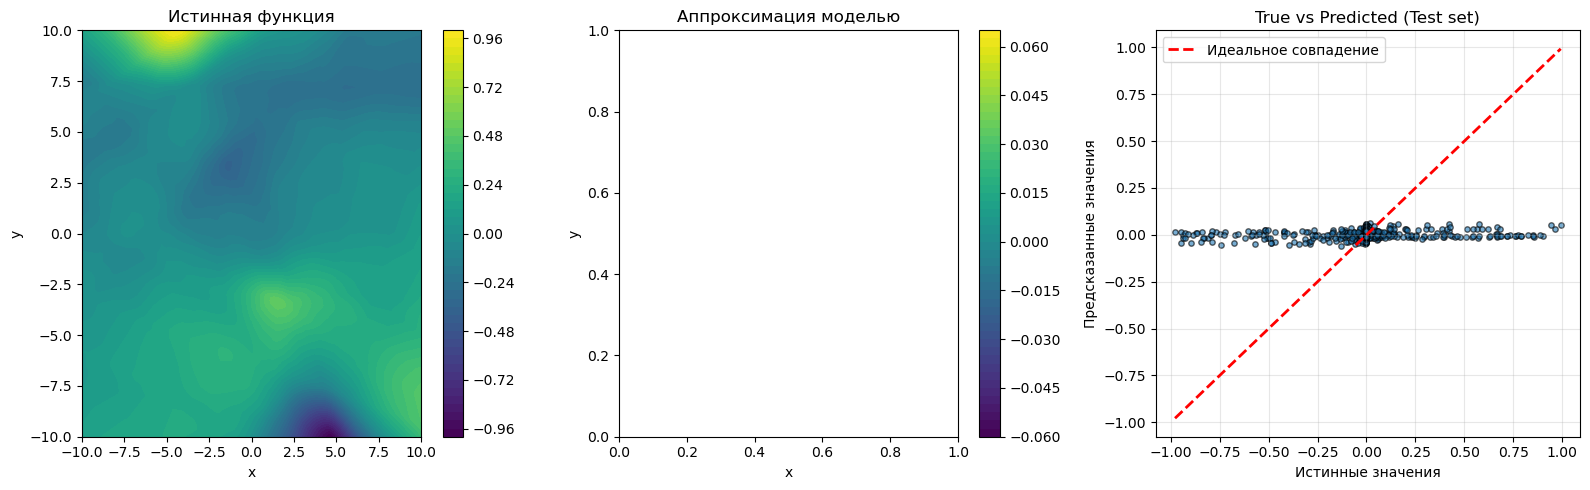

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

# Генерация данных
n_samples = 20000
# Случайные точки в диапазоне [-10, 10]
X = np.random.uniform(-10, 10, size=(n_samples, 2)).astype(np.float32)
# Целевая функция
y = np.sin(X[:, 0] + 2 * X[:, 1]) * np.exp(-(2 * X[:, 0] + X[:, 1])**2)
y = y.astype(np.float32).reshape(-1, 1)  # Приводим к форме (N, 1)

# Нормализация входов
X_min, X_max = -10.0, 10.0
X_norm = (X - X_min) / (X_max - X_min) * 2 - 1  # Масштабирование в [-1, 1]

# Разделение на train / val / test (70% / 15% / 15%)
dataset = TensorDataset(torch.tensor(X_norm), torch.tensor(y))
train_size = int(0.7 * n_samples)   # 14000
val_size = int(0.15 * n_samples)    # 3000
test_size = n_samples - train_size - val_size  # 3000

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

# Создаем DataLoader для пакетной обработки
batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)
test_loader = DataLoader(test_ds, batch_size=batch_size)

# Определение модели 
class MLPRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
        
    def forward(self, x):
        return self.network(x)

model = MLPRegressor()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Обучение модели
epochs = 2
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= train_size

    # Валидация
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            val_loss += criterion(y_pred, y_batch).item() * X_batch.size(0)
    val_loss /= val_size

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")

# Оценка на test (результат a)
model.eval()
test_loss = 0.0
y_test_true = []
y_test_pred = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)
        test_loss += criterion(y_pred, y_batch).item() * X_batch.size(0)
        y_test_true.extend(y_batch.squeeze().tolist())
        y_test_pred.extend(y_pred.squeeze().tolist())

test_loss /= test_size
print(f"Итоговый MSE на test: {test_loss:.6f}")

# Визуализация (результат b)
grid_res = 150
x_grid = np.linspace(-10, 10, grid_res)
y_grid = np.linspace(-10, 10, grid_res)
Xg, Yg = np.meshgrid(x_grid, y_grid)
grid_points = np.column_stack((Xg.ravel(), Yg.ravel()))

grid_norm = (grid_points - X_min) / (X_max - X_min) * 2 - 1
grid_tensor = torch.tensor(grid_norm, dtype=torch.float32)

with torch.no_grad():
    Z_pred = model(grid_tensor).numpy().reshape(grid_res, grid_res)

# Истинные значения на сетке
Z_true = np.sin(Xg + 2*Yg) * np.exp(-(2*Xg + Yg)**2)

# Построение графиков
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Истинная функция
c1 = axes[0].contourf(Xg, Yg, Z_true, levels=50, cmap='viridis')
axes[0].set_title('Истинная функция')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
fig.colorbar(c1, ax=axes[0])

# Аппроксимация моделью
c2 = axes[0].contourf(Xg, Yg, Z_pred, levels=50, cmap='viridis')
axes[1].set_title('Аппроксимация моделью')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
fig.colorbar(c2, ax=axes[1])

# Scatter-график: True vs Predicted
axes[2].scatter(y_test_true, y_test_pred, alpha=0.6, s=15, edgecolor='k')
min_v, max_v = min(y_test_true + y_test_pred), max(y_test_true + y_test_pred)
axes[2].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Идеальное совпадение')
axes[2].set_xlabel('Истинные значения')
axes[2].set_ylabel('Предсказанные значения')
axes[2].set_title('True vs Predicted (Test set)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()